Instalación de librerías necesarias

In [1]:
! pip install pandas scikit-learn seaborn matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable


Configuración e importación de librerías para el modelo

In [2]:
import sys
sys.path.append('../../')

# Importar librerías necesarias
Este notebook replica el flujo de `model_irca.py` para análisis y entrenamiento de un modelo de red neuronal para regresión.

In [3]:
# 1. Importar librerías
from app.database import get_db
from app.services import resultado
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score, max_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

In [4]:
# 2. Obtener datos de la base de datos
db = next(get_db())
resultados = resultado.get_resultados(db)
df = pd.DataFrame(resultados)

In [5]:
# 3. Análisis de nulos y limpieza de columnas
porcentajes_nulos = df.isnull().mean() * 100
umbral_eliminar = 70  # eliminar columnas con >70% de nulos
columnas_eliminar = porcentajes_nulos[porcentajes_nulos > umbral_eliminar].index.tolist()
df = df.drop(columns=columnas_eliminar)

In [6]:
# 4. Selección y limpieza de columnas numéricas y categóricas
numerical_columns = [col for col in df.columns if 'resultado' in col.lower()]
categorical_columns = [col for col in df.columns if 'diagnostico' in col.lower()]
df.drop(columns=categorical_columns, inplace=True)
df.drop(columns=['nivel_Riesgo'], inplace=True)
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['IRCA'] = pd.to_numeric(df['IRCA'], errors='coerce')

In [7]:
# 5. Imputación de valores nulos en columnas numéricas
imputer_num = SimpleImputer(strategy="median")
df[numerical_columns] = imputer_num.fit_transform(df[numerical_columns])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15376 entries, 0 to 15375
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   resultado_Color_Aparente        15376 non-null  float64
 1   resultado_Turbiedad             15376 non-null  float64
 2   resultado_Ph                    15376 non-null  float64
 3   resultado_Cloro_Residual_Libre  15376 non-null  float64
 4   resultado_Cloruros              15376 non-null  float64
 5   resultado_Nitritos              15376 non-null  float64
 6   resultado_Coliformes_Totales    15376 non-null  float64
 7   resultado_E_Coli                15376 non-null  float64
 8   IRCA                            15376 non-null  float64
dtypes: float64(9)
memory usage: 1.1 MB


In [9]:
# 6. División de datos en características y objetivo
X = df.drop(columns=['IRCA'], axis=1)
y = df['IRCA']

In [10]:
# 7. Normalización de datos
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.values.reshape(-1, 1)).flatten()
print(X.shape, y.shape)

(15376, 8) (15376,)


In [11]:
# 8. División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# 9. Creación y entrenamiento del modelo
model = MLPRegressor(hidden_layer_sizes=(16,), 
                     activation='relu', 
                     solver='adam', 
                     learning_rate='adaptive', 
                     learning_rate_init=0.001,
                     max_iter=1000, 
                     random_state=42, 
                     validation_fraction=0.1, 
                     n_iter_no_change=20, 
                     verbose=True)
history = model.fit(X_train, y_train)

Iteration 1, loss = 1.05391513
Iteration 2, loss = 0.60573667
Iteration 3, loss = 0.40176178
Iteration 4, loss = 0.30369664


Iteration 5, loss = 0.25307959
Iteration 6, loss = 0.22181096
Iteration 7, loss = 0.20046482
Iteration 8, loss = 0.18606501
Iteration 9, loss = 0.17630725
Iteration 10, loss = 0.16878615
Iteration 11, loss = 0.16308397
Iteration 12, loss = 0.15843802
Iteration 13, loss = 0.15459560
Iteration 14, loss = 0.15155947
Iteration 15, loss = 0.14862594
Iteration 16, loss = 0.14602530
Iteration 17, loss = 0.14365263
Iteration 18, loss = 0.14153825
Iteration 19, loss = 0.13960257
Iteration 20, loss = 0.13778802
Iteration 21, loss = 0.13611000
Iteration 22, loss = 0.13452495
Iteration 23, loss = 0.13297264
Iteration 24, loss = 0.13158826
Iteration 25, loss = 0.13026511
Iteration 26, loss = 0.12895952
Iteration 27, loss = 0.12765058
Iteration 28, loss = 0.12643369
Iteration 29, loss = 0.12526401
Iteration 30, loss = 0.12419039
Iteration 31, loss = 0.12310887
Iteration 32, loss = 0.12195024
Iteration 33, loss = 0.12112229
Iteration 34, loss = 0.12002681
Iteration 35, loss = 0.11899729
Iteration 36,

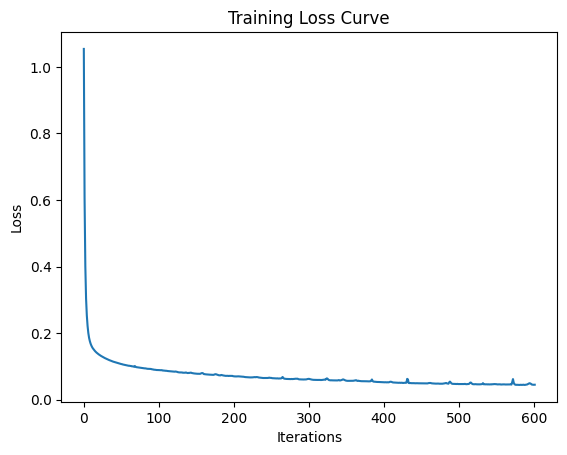

In [13]:
plt.plot(history.loss_curve_)
plt.title('Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

In [14]:
# 10. Evaluación del modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")
print(f"Explained Variance Score: {evs}")
print(f"Max Error: {max_err}")
print(f"Mean Absolute Percentage Error: {mape}")

Mean Squared Error: 0.08494638329715362
R^2 Score: 0.9161353539594668
Mean Absolute Error: 0.19692332080180222
Explained Variance Score: 0.9161840364111756
Max Error: 2.3999628714142016
Mean Absolute Percentage Error: 0.4498745257367185


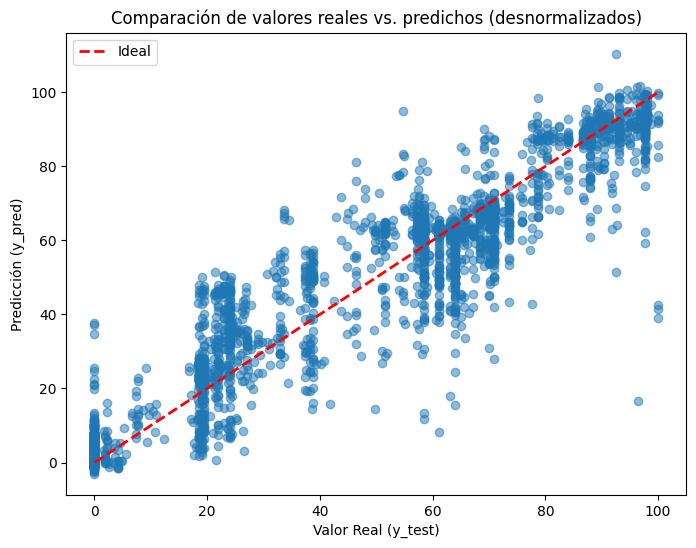

In [15]:
y_scaler = StandardScaler()
y_scaler.fit(df['IRCA'].values.reshape(-1, 1))  

y_test_desnorm = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_desnorm = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()


plt.figure(figsize=(8, 6))
plt.scatter(y_test_desnorm, y_pred_desnorm, alpha=0.5)
plt.plot([y_test_desnorm.min(), y_test_desnorm.max()], [y_test_desnorm.min(), y_test_desnorm.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Valor Real (y_test)')
plt.ylabel('Predicción (y_pred)')
plt.title('Comparación de valores reales vs. predichos (desnormalizados)')
plt.legend()
plt.show()

# Análisis visual y métricas adicionales
A continuación se agregan visualizaciones y métricas para analizar los errores del modelo y la relación entre predicción y valor real.

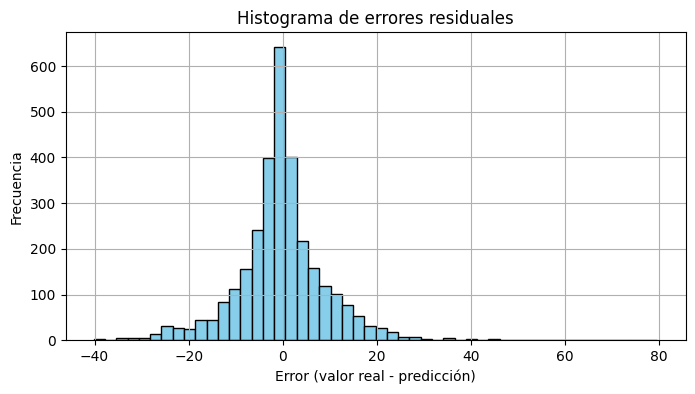

In [16]:
# 1. Histograma de errores residuales
residuals = y_test_desnorm - y_pred_desnorm
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='skyblue', edgecolor='black')
plt.title('Histograma de errores residuales')
plt.xlabel('Error (valor real - predicción)')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

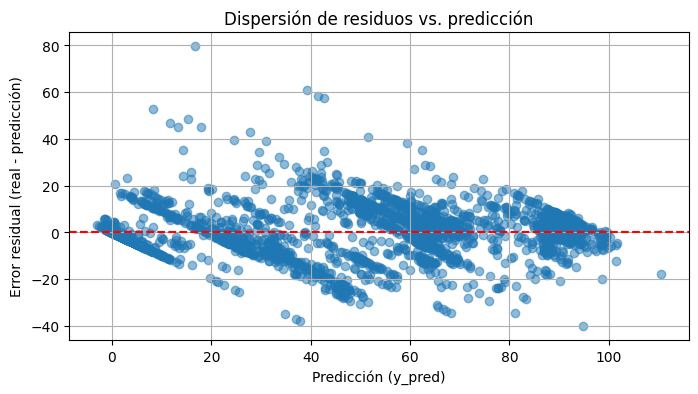

In [17]:
# 2. Gráfico de dispersión de residuos
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_desnorm, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicción (y_pred)')
plt.ylabel('Error residual (real - predicción)')
plt.title('Dispersión de residuos vs. predicción')
plt.grid()
plt.show()

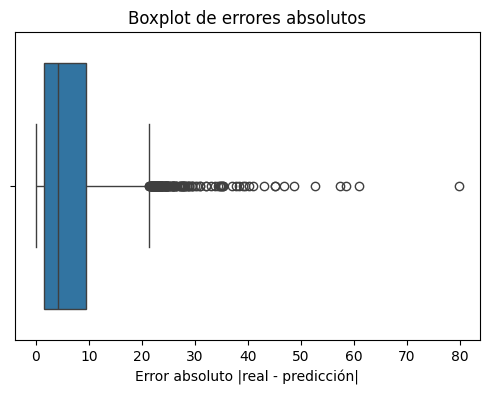

In [18]:
# 3. Boxplot de errores absolutos
plt.figure(figsize=(6, 4))
sns.boxplot(x=np.abs(residuals))
plt.title('Boxplot de errores absolutos')
plt.xlabel('Error absoluto |real - predicción|')
plt.show()

In [19]:
# 4. Métricas adicionales
rmse = np.sqrt(mean_squared_error(y_test_desnorm, y_pred_desnorm))
medae = np.median(np.abs(y_test_desnorm - y_pred_desnorm))
pearson_corr, _ = pearsonr(y_test_desnorm, y_pred_desnorm)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mediana del error absoluto (MedAE): {medae:.4f}")
print(f"Coeficiente de correlación de Pearson: {pearson_corr:.4f}")

Root Mean Squared Error (RMSE): 9.6847
Mediana del error absoluto (MedAE): 4.0914
Coeficiente de correlación de Pearson: 0.9572


# Explicación de las métricas de evaluación del modelo

A continuación se describen las principales métricas utilizadas para evaluar el desempeño de un modelo de regresión, junto con ejemplos numéricos:

- **Error cuadrático medio (MSE)**
  - Mide el promedio de los errores al cuadrado entre los valores reales y las predicciones.
  - Fórmula:
    $$
    \text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
    $$
  - Ejemplo: Si $y = [2, 3, 5]$ y $\hat{y} = [2.5, 2.8, 4.9]$:
    $$
    \text{MSE} = \frac{1}{3} [(2-2.5)^2 + (3-2.8)^2 + (5-4.9)^2] = \frac{1}{3} [0.25 + 0.04 + 0.01] = 0.1
    $$

- **Raíz del error cuadrático medio (RMSE)**
  - Es la raíz cuadrada del MSE, por lo que tiene las mismas unidades que la variable objetivo.
  - Fórmula:
    $$
    \text{RMSE} = \sqrt{\text{MSE}}
    $$
  - Ejemplo: $\text{RMSE} = \sqrt{0.1} \approx 0.316$

- **Coeficiente de determinación ($R^2$)**
  - Indica la proporción de la varianza de los datos explicada por el modelo.
  - Fórmula:
    $$
    R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
    $$
  - Ejemplo: Si $\sum (y_i - \hat{y}_i)^2 = 0.3$ y $\sum (y_i - \bar{y})^2 = 2.0$:
    $$
    R^2 = 1 - \frac{0.3}{2.0} = 0.85
    $$

- **Error absoluto medio (MAE)**
  - Mide el promedio de los errores absolutos entre los valores reales y las predicciones.
  - Fórmula:
    $$
    \text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
    $$
  - Ejemplo: $\text{MAE} = \frac{1}{3} (|2-2.5| + |3-2.8| + |5-4.9|) = \frac{1}{3} (0.5 + 0.2 + 0.1) = 0.267$

- **Mediana del error absoluto (MedAE)**
  - Es la mediana de los errores absolutos. Para los errores $[0.5, 0.2, 0.1]$ ordenados: $[0.1, 0.2, 0.5]$, la mediana es $0.2$.

- **Varianza explicada (EVS)**
  - Mide la proporción de la varianza total explicada por el modelo. Similar a $R^2$.

- **Error absoluto máximo (Max Error)**
  - Es el mayor error absoluto observado entre las predicciones y los valores reales. En el ejemplo anterior: $\max([0.5, 0.2, 0.1]) = 0.5$

- **Error porcentual absoluto medio (MAPE)**
  - Mide el error absoluto medio en términos porcentuales.
  - Fórmula:
    $$
    \text{MAPE} = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|
    $$
  - Ejemplo: $\text{MAPE} = \frac{100\%}{3} (|2-2.5|/2 + |3-2.8|/3 + |5-4.9|/5) = \frac{100\%}{3} (0.25 + 0.0667 + 0.02) \approx 11.23\%$

- **Coeficiente de correlación de Pearson**
  - Mide la fuerza y dirección de la relación lineal entre las predicciones y los valores reales. Valores cercanos a 1 indican una correlación fuerte y positiva.

Estas métricas permiten evaluar el desempeño de un modelo de regresión desde diferentes perspectivas y facilitan la comparación entre modelos.